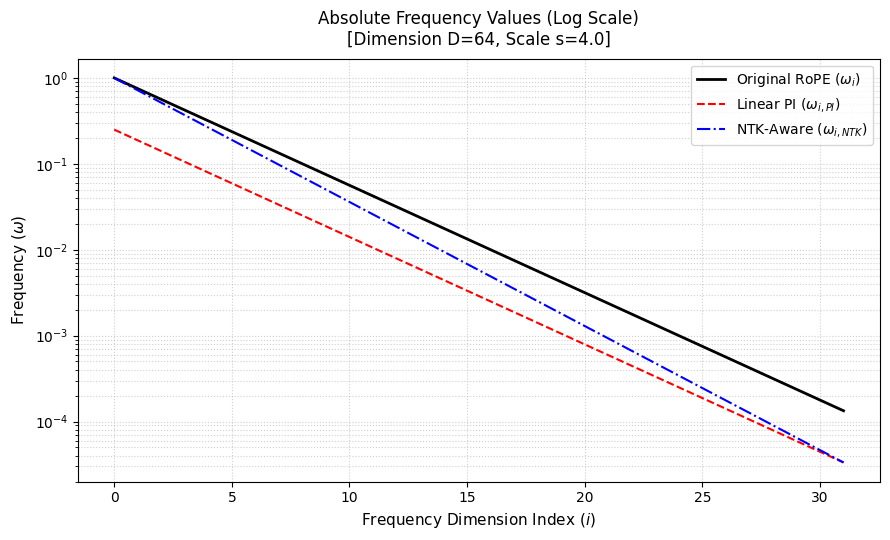

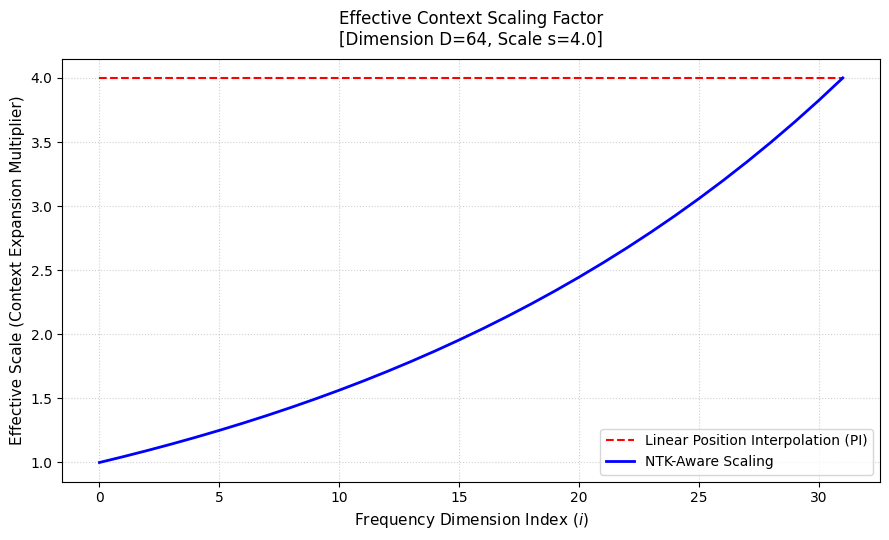

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_rope_frequencies(dim, base=10000):
    i = np.arange(0, dim // 2)
    omega = 1.0 / (base ** (2 * i / dim))
    return i, omega

def get_linear_pi_frequencies(dim, scale, base=10000):
    _, omega = get_rope_frequencies(dim, base)
    return omega / scale

def get_ntk_alpha_frequencies(dim, scale, base=10000):
    base_prime = base * (scale ** (dim / (dim - 2)))
    i = np.arange(0, dim // 2)
    omega_ntk = 1.0 / (base_prime ** (2 * i / dim))
    return omega_ntk

# Parameters
D = 64          # Hidden dimension size
scale = 4.0     # Context expansion factor

# Calculate data
i, freq_base = get_rope_frequencies(D)
freq_pi = get_linear_pi_frequencies(D, scale)
freq_ntk = get_ntk_alpha_frequencies(D, scale)

effective_scale_pi = freq_base / freq_pi
effective_scale_ntk = freq_base / freq_ntk

# =====================================================================
# PLOT 1: Absolute Frequency Values Comparison
# =====================================================================
plt.figure(figsize=(9, 5.5))
plt.plot(i, freq_base, label="Original RoPE ($\omega_i$)", color="black", linewidth=2)
plt.plot(i, freq_pi, label="Linear PI ($\omega_{i,PI}$)", color="red", linestyle="--")
plt.plot(i, freq_ntk, label="NTK-Aware ($\omega_{i,NTK}$)", color="blue", linestyle="-.")

plt.yscale('log')
plt.title(f"Absolute Frequency Values (Log Scale)\n[Dimension D={D}, Scale s={scale}]", fontsize=12, pad=10)
plt.xlabel("Frequency Dimension Index ($i$)", fontsize=11)
plt.ylabel("Frequency ($\omega$)", fontsize=11)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# =====================================================================
# PLOT 2: Effective Context Scaling Factor
# =====================================================================
plt.figure(figsize=(9, 5.5))
plt.plot(i, effective_scale_pi, label="Linear Position Interpolation (PI)", linestyle="--", color="red")
plt.plot(i, effective_scale_ntk, label="NTK-Aware Scaling", linewidth=2, color="blue")

plt.title(f"Effective Context Scaling Factor\n[Dimension D={D}, Scale s={scale}]", fontsize=12, pad=10)
plt.xlabel("Frequency Dimension Index ($i$)", fontsize=11)
plt.ylabel("Effective Scale (Context Expansion Multiplier)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()